# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. <br>6 = Myle Technologies Inc|
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride <br>99 = Null/unknown|
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Import the libraries you will be using for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pip install numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 75.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-

In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [4]:
# Try loading one file

df = pd.read_parquet('/content/drive/MyDrive/Assignments/EDA/data_NYC_Taxi/trip_records/2023-1.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('/content/drive/MyDrive/Assignments/EDA/data_NYC_Taxi/trip_records')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        monthly = pd.read_parquet(file_path)

        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        monthly['date'] = monthly["tpep_pickup_datetime"].dt.date
        monthly['hour'] = monthly["tpep_pickup_datetime"].dt.hour
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        for date_value in sorted(monthly['date'].unique()):
            date_df = monthly[monthly['date'] == date_value]
            # Iterate through each hour of the selected date
            for h in range(24):
                hour_data = date_df[date_df['hour'] == h]
                # Sample 5%(used=0.008) of the hourly data randomly
                sample = hour_data.sample(frac = 0.008, random_state = 42)
                # add data of this hour to the dataframe
                sampled_data = pd.concat([sampled_data, sample], ignore_index=True)
        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, sampled_data], ignore_index=True)# we initialised this empty DF earlier

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [ ]:
# Store the df in csv/parquet
df.to_csv('taxi_sample_01.csv')

In [6]:
# To ensure my data is perfectly random sampled
# Convert to datetime
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], errors='coerce')
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'], errors='coerce')

# Extract pickup and dropoff months
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
df['dropoff_month'] = df['tpep_dropoff_datetime'].dt.month

# Compute proportions
pickup_prop = df['pickup_month'].value_counts(normalize=True).sort_index()
dropoff_prop = df['dropoff_month'].value_counts(normalize=True).sort_index()

print(pickup_prop)
print(dropoff_prop)

pickup_month
1     0.080218
2     0.076181
3     0.088926
4     0.085920
5     0.091754
6     0.086359
7     0.075828
8     0.073613
9     0.074315
10    0.091880
11    0.087091
12    0.087915
Name: proportion, dtype: float64
dropoff_month
1     0.080202
2     0.076191
3     0.088900
4     0.085927
5     0.091774
6     0.086336
7     0.075845
8     0.073600
9     0.074312
10    0.091899
11    0.087064
12    0.087951
Name: proportion, dtype: float64


## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [5]:
# Load the new data file
df = pd.read_csv("/content/drive/MyDrive/Assignments/EDA/data_NYC_Taxi/trip_records/taxi_sample.csv")
df.shape

(303397, 23)

In [ ]:
df.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,date,hour,Airport_fee,pickup_month,dropoff_month
0,0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,...,0.0,1.0,41.15,0.0,1.25,2023-01-01,0,NaN,1,1
1,1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,...,0.0,1.0,15.48,2.5,0.00,2023-01-01,0,NaN,1,1
2,2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,...,0.0,1.0,16.40,2.5,0.00,2023-01-01,0,NaN,1,1
3,3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,...,0.0,1.0,11.50,2.5,0.00,2023-01-01,0,NaN,1,1
4,4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,NaN,66,107,...,0.0,1.0,35.57,NaN,NaN,2023-01-01,0,NaN,1,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303397 entries, 0 to 303396
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   Unnamed: 0             303397 non-null  int64         
 1   VendorID               303397 non-null  int64         
 2   tpep_pickup_datetime   303397 non-null  datetime64[ns]
 3   tpep_dropoff_datetime  303397 non-null  datetime64[ns]
 4   passenger_count        293215 non-null  float64       
 5   trip_distance          303397 non-null  float64       
 6   RatecodeID             293215 non-null  float64       
 7   store_and_fwd_flag     293215 non-null  object        
 8   PULocationID           303397 non-null  int64         
 9   DOLocationID           303397 non-null  int64         
 10  payment_type           303397 non-null  int64         
 11  fare_amount            303397 non-null  float64       
 12  extra                  303397 non-null  floa

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [8]:
# Fix the index and drop any columns that are not needed
ColumnsToDrop = ['Unnamed: 0','store_and_fwd_flag', 'mta_tax', 'tolls_amount','date']
df = df.drop(columns=ColumnsToDrop).reset_index(drop="True")
df.shape

(303397, 20)

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

<font color="yellow">airport_fee column have more null values than Airport_fee column, so we can dilute airport_fee and keep Airport_fee column</font>

In [9]:
# Combine the two airport fee columns
df['airport_fee'] = df["airport_fee"].fillna(df["Airport_fee"])
# deleting redundant column
df = df.drop(columns=["Airport_fee"])

In [10]:
df = df.rename(columns={"hour":"pickup_hour"})

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [11]:
# check where values of fare amount are negative
len(df[df["fare_amount"] < 0])

0

Did you notice something different in the `RatecodeID` column for above records?

In [26]:
# Analyse RatecodeID for the negative fare amounts
df["RatecodeID"].value_counts()

,count
RatecodeID,
1.0,287009
2.0,11458
99.0,1727
5.0,1650
3.0,961
4.0,580


In [13]:
df.describe()   # checking all negative value columns

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,tip_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,pickup_month,dropoff_month
count,303397.000000,303397,303397,293215.000000,303397.00000,293215.000000,303397.000000,303397.000000,303397.000000,303397.000000,303397.000000,303397.000000,303397.000000,303397.000000,293215.000000,293215.000000,303397.000000,303397.000000,303397.000000
mean,1.733745,2023-07-02 20:05:06.574544640,2023-07-02 20:22:26.117786368,1.366970,3.55859,1.651300,165.251924,163.911871,1.164781,20.280354,1.584759,3.543435,0.998974,29.331403,2.308605,0.141998,14.265256,6.540269,6.540503
min,1.000000,2023-01-01 00:04:34,2023-01-01 00:09:40,0.000000,0.00000,1.000000,1.000000,1.000000,0.000000,0.000000,-2.500000,0.000000,-1.000000,-4.000000,-2.500000,-1.750000,0.000000,1.000000,1.000000
25%,1.000000,2023-04-02 16:03:02,2023-04-02 16:18:03,1.000000,1.05000,1.000000,132.000000,113.000000,1.000000,9.300000,0.000000,1.000000,1.000000,15.960000,2.500000,0.000000,11.000000,4.000000,4.000000
50%,2.000000,2023-06-27 15:54:33,2023-06-27 16:15:56,1.000000,1.80000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,2.840000,1.000000,21.000000,2.500000,0.000000,15.000000,6.000000,6.000000
75%,2.000000,2023-10-06 19:40:23,2023-10-06 19:54:39,1.000000,3.40000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,4.420000,1.000000,30.800000,2.500000,0.000000,19.000000,10.000000,10.000000
max,6.000000,2023-12-31 23:54:03,2024-01-01 20:14:57,9.000000,22528.82000,99.000000,265.000000,265.000000,4.000000,143163.450000,14.250000,150.290000,1.000000,143167.450000,2.500000,1.750000,23.000000,12.000000,12.000000
std,0.447484,NaN,NaN,0.890697,45.48573,7.503493,64.054580,69.795454,0.507151,260.510055,1.822959,4.046205,0.030897,260.857909,0.664916,0.463270,5.807113,3.466936,3.466965


In [14]:
# Find which columns have negative values
numeric_col = ['extra', 'improvement_surcharge','total_amount', 'congestion_surcharge', 'airport_fee']
for col in numeric_col:
    if (df[col] < 0).any():
        print(f"{col}: {len(df[df[col] < 0])}")

extra: 1
improvement_surcharge: 11
total_amount: 11
congestion_surcharge: 6
airport_fee: 2


In [15]:
# fix these negative values while preserving NaN values
for col in numeric_col:
    df = df[(df[col] >= 0) | df[col].isnull()]

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [16]:
# Find the proportion of missing values in each column
missing_values_proportion = df.isnull().mean() * 100
missing_values_proportion

,0
VendorID,0.000000
tpep_pickup_datetime,0.000000
tpep_dropoff_datetime,0.000000
passenger_count,3.356132
trip_distance,0.000000
RatecodeID,3.356132
PULocationID,0.000000
DOLocationID,0.000000
payment_type,0.000000
fare_amount,0.000000


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [17]:
df[df['passenger_count'].isnull()].shape

(10182, 19)

In [18]:
median_passenger_count = df['passenger_count'].median()
median_passenger_count

1.0

In [19]:
# Display the rows with null values
df[df['passenger_count'].isnull()]

# Impute NaN values in 'passenger_count'
df['passenger_count'] = df['passenger_count'].fillna(median_passenger_count)

Did you find zeroes in passenger_count? Handle these.

<font color="yellow">Filled all missing values and unwanted zero passenger count values with a median of 1.0, as zero passenger count rows indicate some fare amount, suggesting there must be passengers.</font>

In [20]:
df['passenger_count'] = df['passenger_count'].replace(0, median_passenger_count)

In [21]:
#confirming no null values
df['passenger_count'].isnull().sum()

0

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [22]:
# Fix missing values in 'RatecodeID'
Mode_RatecodeID = df["RatecodeID"].value_counts().index[0]  # since it is a categorical data fixing missing values with mode
df["RatecodeID"] = df["RatecodeID"].fillna(Mode_RatecodeID)

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [23]:
# handle null values in congestion_surcharge
df["congestion_surcharge"] = df["congestion_surcharge"].fillna(0) # replacing missing value with 0

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

<font color="yellow">All missing values for airport fees have been replaced with 0, assuming that there were no visits to the airport.</font>

In [24]:
# Handle any remaining missing values
df['airport_fee'] = df['airport_fee'].fillna(0)

In [ ]:
# checking for missing values
df.isnull().mean()*100

,0
VendorID,0.0
tpep_pickup_datetime,0.0
tpep_dropoff_datetime,0.0
passenger_count,0.0
trip_distance,0.0
RatecodeID,0.0
PULocationID,0.0
DOLocationID,0.0
payment_type,0.0
fare_amount,0.0


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [27]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,tip_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,pickup_month,dropoff_month
count,303385.000000,303385,303385,303385.000000,303385.000000,303385.000000,303385.000000,303385.000000,303385.000000,303385.000000,303385.000000,303385.000000,303385.000000,303385.000000,303385.000000,303385.00000,303385.000000,303385.000000,303385.000000
mean,1.733734,2023-07-02 20:03:08.088557056,2023-07-02 20:20:27.658292224,1.369999,3.558681,1.629451,165.251608,163.910609,1.164741,20.281146,1.584830,3.543576,0.999047,29.332665,2.231266,0.13725,14.265204,6.540224,6.540458
min,1.000000,2023-01-01 00:04:34,2023-01-01 00:09:40,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,1.000000
25%,1.000000,2023-04-02 16:02:35,2023-04-02 16:16:52,1.000000,1.050000,1.000000,132.000000,113.000000,1.000000,9.300000,0.000000,1.000000,1.000000,15.960000,2.500000,0.00000,11.000000,4.000000,4.000000
50%,2.000000,2023-06-27 15:52:02,2023-06-27 16:15:18,1.000000,1.800000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,2.840000,1.000000,21.000000,2.500000,0.00000,15.000000,6.000000,6.000000
75%,2.000000,2023-10-06 19:36:08,2023-10-06 19:53:19,1.000000,3.400000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,4.420000,1.000000,30.800000,2.500000,0.00000,19.000000,10.000000,10.000000
max,6.000000,2023-12-31 23:54:03,2024-01-01 20:14:57,9.000000,22528.820000,99.000000,265.000000,265.000000,4.000000,143163.450000,14.250000,150.290000,1.000000,143167.450000,2.500000,1.75000,23.000000,12.000000,12.000000
std,0.447490,NaN,NaN,0.862931,45.486625,7.377588,64.054323,69.795769,0.507109,260.515176,1.822955,4.046224,0.028456,260.862990,0.774351,0.45613,5.807172,3.466944,3.466973


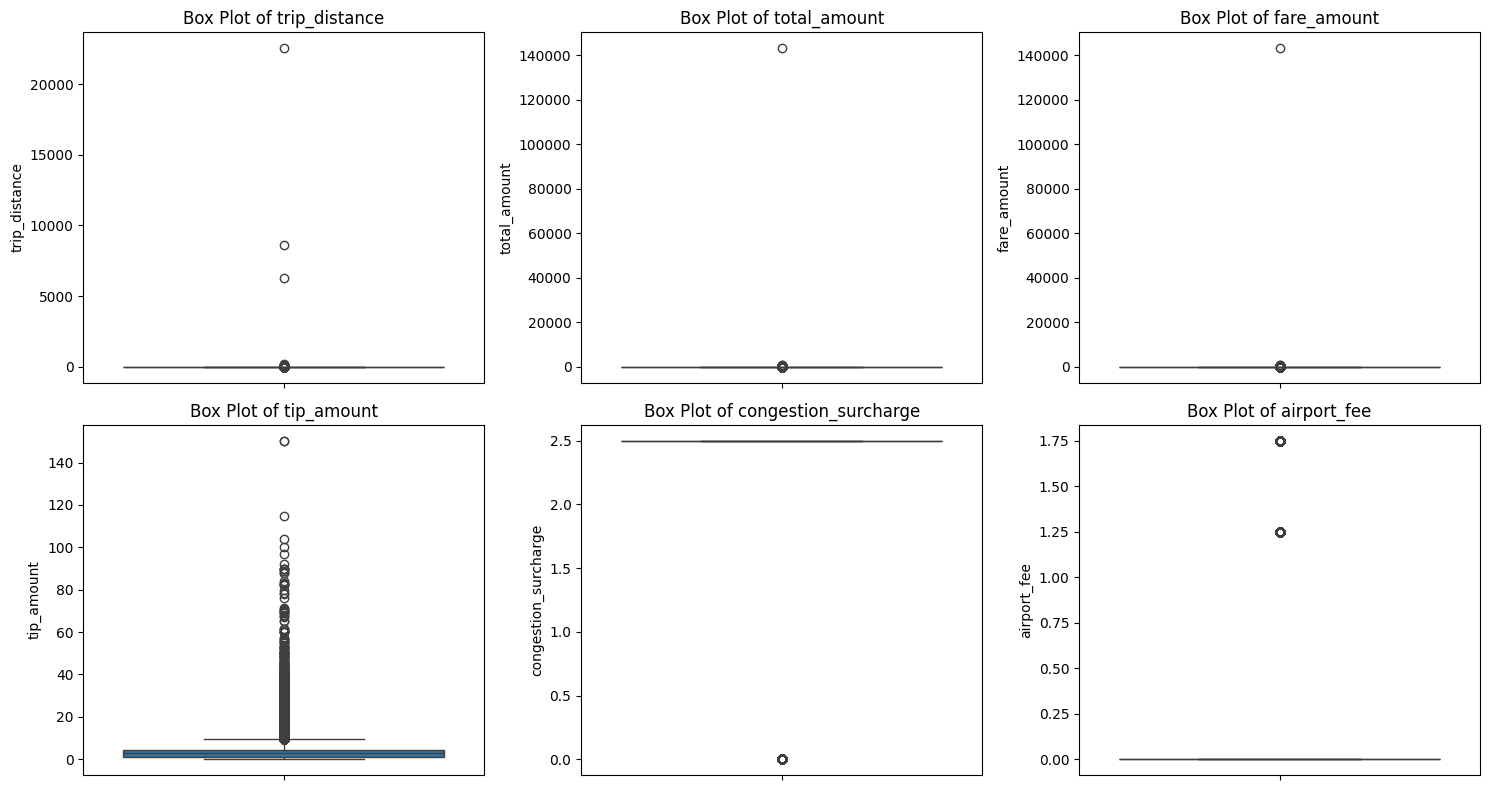

In [29]:
columns_to_plot = ['trip_distance', 'total_amount', 'fare_amount', 'tip_amount', 'congestion_surcharge', 'airport_fee']

# Calculate the number of rows and columns for subplots
num_columns = len(columns_to_plot)
num_cols_per_row = 3 # You can adjust this number
num_rows = (num_columns + num_cols_per_row - 1) // num_cols_per_row

fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(5 * num_cols_per_row, 4 * num_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(columns_to_plot):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_ylabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [30]:
# remove passenger_count > 6
df = df[df["passenger_count"] <= 6]

In [31]:
# Continue with outlier handling

# Entries where trip_distance is nearly 0 and fare_amount is more than 300
out1 = (df['trip_distance'] <= 0.1) & (df['fare_amount'] > 300)
df = df[~out1]

# Entries where trip_distance and fare_amount are 0 but the pickup and dropoff zones are different
out2 = (df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID'])
df = df[~out2]

# Entries where trip_distance is more than 250 miles.
out3 = df['trip_distance'] > 250
df = df[~out3]

# Entries where payment_type is 0
out4 = df['payment_type'] == 0
df = df[~out4]

In [32]:
df = df[(df["fare_amount"] < 500) & (df["total_amount"]<500)]

In [33]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,tip_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,pickup_month,dropoff_month
count,293184.000000,293184,293184,293184.000000,293184.000000,293184.000000,293184.000000,293184.000000,293184.000000,293184.000000,293184.000000,293184.000000,293184.000000,293184.000000,293184.000000,293184.000000,293184.000000,293184.000000,293184.000000
mean,1.737059,2023-07-01 21:10:15.759238912,2023-07-01 21:27:31.428775168,1.382732,3.436502,1.650813,165.409528,164.179860,1.205148,19.709044,1.634099,3.571676,0.999344,28.822897,2.308857,0.142007,14.298939,6.509370,6.509601
min,1.000000,2023-01-01 00:04:34,2023-01-01 00:09:40,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,1.000000,2023-04-01 20:42:23.750000128,2023-04-01 20:57:44.750000128,1.000000,1.060000,1.000000,132.000000,113.000000,1.000000,9.300000,0.000000,1.000000,1.000000,15.960000,2.500000,0.000000,11.000000,4.000000,4.000000
50%,2.000000,2023-06-26 07:55:40.500000,2023-06-26 08:10:00.500000,1.000000,1.790000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,2.860000,1.000000,21.000000,2.500000,0.000000,15.000000,6.000000,6.000000
75%,2.000000,2023-10-05 19:05:51.249999872,2023-10-05 19:23:10.750000128,1.000000,3.360000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,4.450000,1.000000,30.620000,2.500000,0.000000,19.000000,10.000000,10.000000
max,2.000000,2023-12-31 23:54:03,2024-01-01 20:14:57,6.000000,187.350000,99.000000,265.000000,265.000000,4.000000,455.200000,14.250000,150.290000,1.000000,488.700000,2.500000,1.750000,23.000000,12.000000,12.000000
std,0.440231,NaN,NaN,0.874552,4.523656,7.501697,63.748588,69.747675,0.466127,18.119065,1.829709,4.061444,0.023729,22.744853,0.664321,0.463237,5.774632,3.462173,3.462193


In [34]:
df.shape

(293184, 19)

In [ ]:
# Do any columns need standardising?

<font color="yellow">No further standardisation was required because the analysis relies primarily on correlation, aggregation, and visualization techniques, which are not affected by differences in variable scale. Additionally, outliers were already treated, and keeping values in their original units (miles, dollars, hours) preserves business interpretability. Standardisation would only be necessary if distance-based machine learning models were applied.</font>

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [35]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'tip_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'pickup_hour',
 'pickup_month',
 'dropoff_month']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

In [36]:
# Creating new column "trip_duration" from pickup and dropff columns
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], errors='coerce')
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'], errors='coerce')
# new trip_duration column in minutes
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60.0

In [37]:
df[df['trip_duration']<0].shape[0]   # rows with negative trip duration

10

In [38]:
# Removing rows with negative trip durations and extreme outlier
df = df[(df['trip_duration']>=0) & (df['trip_duration']<2000)]

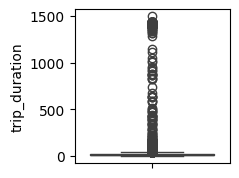

In [39]:
plt.figure(figsize=(2,2))
sns.boxplot(df['trip_duration']);

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

pickup_hour
0      8193
1      5466
2      3602
3      2347
4      1503
5      1575
6      3873
7      7877
8     10917
9     12517
10    13707
11    14911
12    16178
13    16699
14    17870
15    18319
16    18287
17    19774
18    20667
19    18570
20    16594
21    16499
22    15250
23    11978
Name: count, dtype: int64


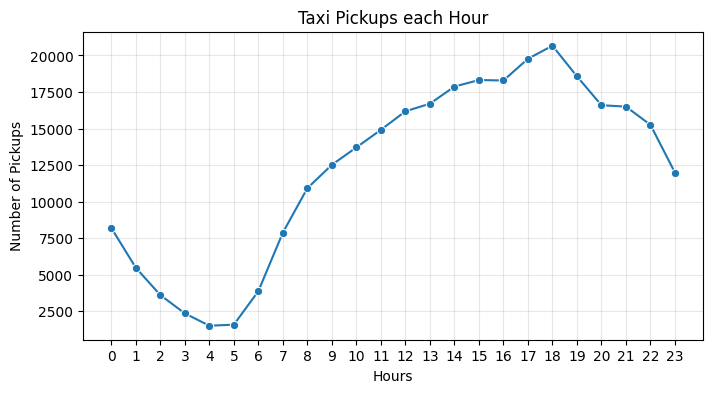

In [40]:
# Find and show the hourly trends in taxi pickups
hourly_pickups = df["pickup_hour"].value_counts().sort_index()
print(hourly_pickups)

plt.figure(figsize=(8,4))
sns.lineplot(x = hourly_pickups.index,y=hourly_pickups.values,marker='o')
plt.title('Taxi Pickups each Hour')
plt.xlabel('Hours')
plt.ylabel('Number of Pickups')
plt.xticks(range(0,24))
plt.grid(True,alpha=0.3);

tpep_pickup_datetime
Monday       36617
Tuesday      42591
Wednesday    45126
Thursday     46004
Friday       43460
Saturday     42541
Sunday       36834
Name: count, dtype: int64


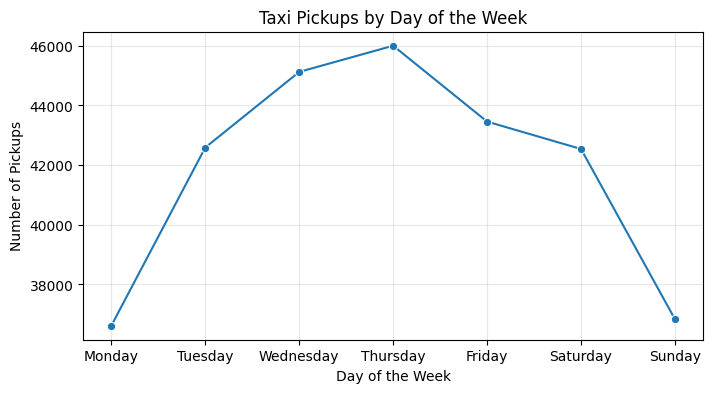

In [41]:
# Find and show the daily trends in taxi pickups (days of the week)
daily_pickups = df['tpep_pickup_datetime'].dt.day_name().value_counts().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
print(daily_pickups)

plt.figure(figsize=(8, 4))
sns.lineplot(x=daily_pickups.index, y=daily_pickups.values,marker='o')
plt.title('Taxi Pickups by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Pickups')
plt.grid(True,alpha=0.3);

tpep_pickup_datetime
Jan    23765
Feb    22519
Mar    26277
Apr    25364
May    27063
Jun    25475
Jul    22354
Aug    21661
Sep    21440
Oct    26692
Nov    25332
Dec    25231
Name: count, dtype: int64


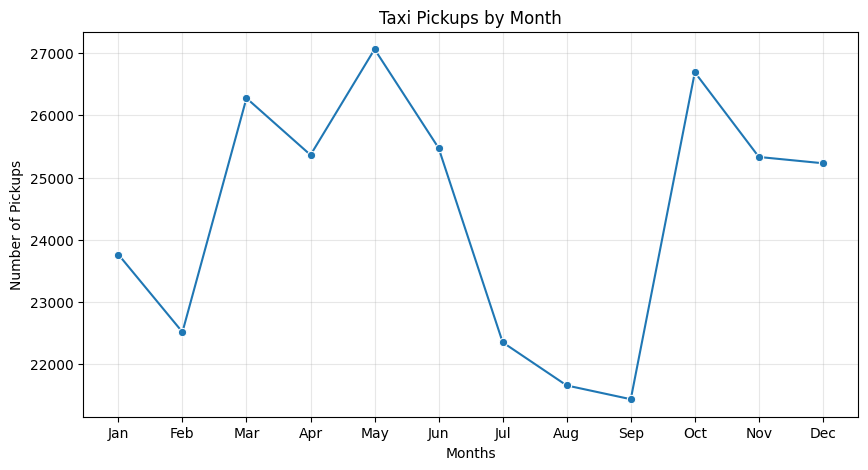

In [42]:
# Show the monthly trends in pickups
monthly_pickups = df['tpep_pickup_datetime'].dt.month.value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_pickups.index = monthly_pickups.index.map(lambda x: month_names[x - 1])

print(monthly_pickups)

plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_pickups.index, y=monthly_pickups.values,marker='o')
plt.title('Taxi Pickups by Month')
plt.xlabel('Months')
plt.ylabel('Number of Pickups')
plt.grid(True,alpha=0.3);

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [43]:
# Analyse the above parameters
df[["fare_amount", "tip_amount", "total_amount", "trip_distance"]].describe()

,fare_amount,tip_amount,total_amount,trip_distance
count,293173.000000,293173.000000,293173.000000,293173.000000
mean,19.708869,3.571668,28.822750,3.436464
std,18.119257,4.061456,22.745097,4.523711
min,0.000000,0.000000,0.000000,0.000000
25%,9.300000,1.000000,15.960000,1.060000
50%,13.500000,2.860000,21.000000,1.790000
75%,21.900000,4.450000,30.620000,3.360000
max,455.200000,150.290000,488.700000,187.350000


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [ ]:
# df ---> df_non_zero

<font color="yellow">Maintaining a zero tip amount considering the passenger did not give a tip to the driver.Additionally, removing a few zero trip distance records that do not impact the dataset. </font>

In [44]:
# Create a df with non zero entries for the selected parameters.
df_non_zero = df[(df["fare_amount"] > 0) & (df["tip_amount"] >= 0) & (df["total_amount"] > 0) & (df["trip_distance"] > 0)].copy()
df_non_zero.shape

(289526, 20)

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

tpep_pickup_datetime
1     641556.95
2     607903.12
3     729746.09
4     713061.98
5     783232.87
6     733939.04
7     630212.26
8     617204.03
9     634893.94
10    784720.46
11    722107.61
12    717563.99
Name: total_amount, dtype: float64


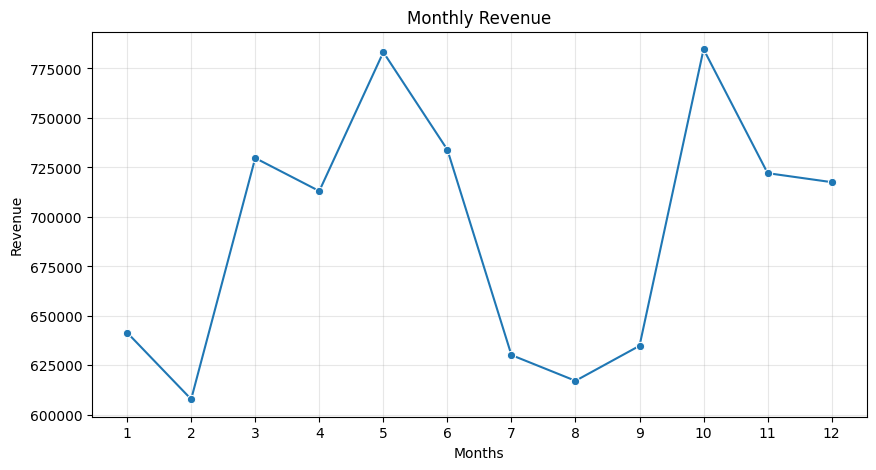

In [45]:
# Group data by month and analyse monthly revenue
monthly_revenue = df_non_zero.groupby(df_non_zero["tpep_pickup_datetime"].dt.month)["total_amount"].sum()
print(monthly_revenue)

plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values,marker="o")
plt.xticks(range(1,13))
plt.xlabel("Months")
plt.ylabel("Revenue")
plt.title("Monthly Revenue")
plt.grid(True,alpha=0.3);

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

Quarterly Revenue Proportion (%):
tpep_pickup_datetime
Q1    23.799571
Q2    26.818130
Q3    22.634416
Q4    26.747883
Name: total_amount, dtype: float64


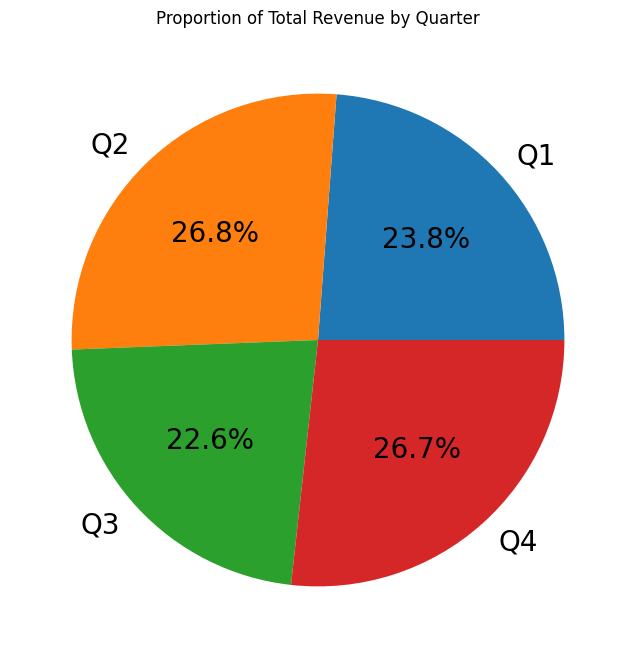

In [46]:
# Calculate proportion of each quarter

# Define quarters using numeric month keys to match monthly_revenue index
numeric_month_to_quarter = {
    1: 'Q1', 2: 'Q1', 3: 'Q1',
    4: 'Q2', 5: 'Q2', 6: 'Q2',
    7: 'Q3', 8: 'Q3', 9: 'Q3',
    10: 'Q4', 11: 'Q4', 12: 'Q4'}

# Map numeric month index to quarters and group by quarter
quarterly_revenue = monthly_revenue.groupby(monthly_revenue.index.map(numeric_month_to_quarter)).sum()

# Calculate the total annual revenue
total_annual_revenue = quarterly_revenue.sum()

# Calculate the proportion for each quarter
quarterly_proportion = (quarterly_revenue / total_annual_revenue) * 100

print("Quarterly Revenue Proportion (%):")
print(quarterly_proportion.sort_index())

plt.figure(figsize=(8, 8))
plt.pie(quarterly_proportion, labels=quarterly_proportion.index, autopct='%1.1f%%',textprops={'fontsize': 20})
plt.title('Proportion of Total Revenue by Quarter');

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

Correlation between trip_distance vs fare_amount:0.943673327088411


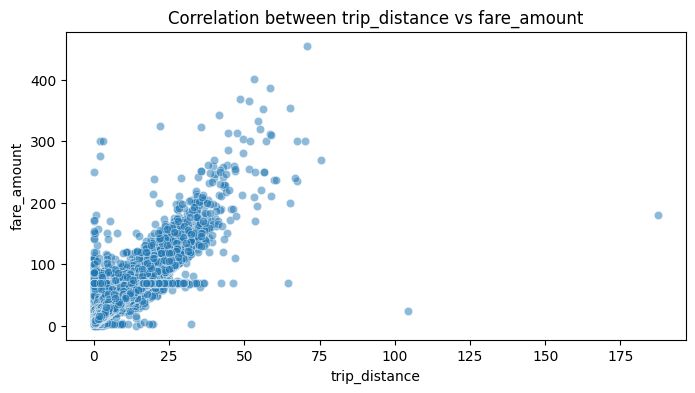

In [47]:
# Show how trip fare is affected by distance
corr_dist_amt = df_non_zero[["trip_distance","fare_amount"]].corr().loc["trip_distance","fare_amount"]
print(f"Correlation between trip_distance vs fare_amount:{corr_dist_amt}")

plt.figure(figsize=(8,4))
sns.scatterplot(data=df_non_zero,y="fare_amount",x="trip_distance",alpha=0.5);
plt.xlabel("trip_distance")
plt.ylabel("fare_amount")
plt.title("Correlation between trip_distance vs fare_amount");

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

Correlation between Fare Amount vs Trip Duration: 0.29


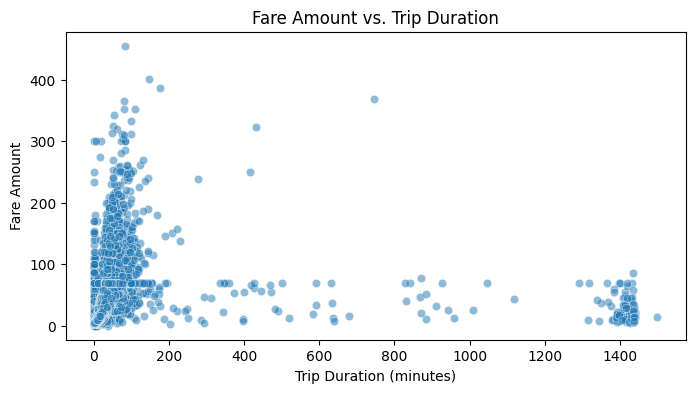

In [48]:
# Show relationship between fare and trip duration
correlation_fare_duration = df_non_zero[['fare_amount', 'trip_duration']].corr().loc['fare_amount', 'trip_duration']
print(f"Correlation between Fare Amount vs Trip Duration: {correlation_fare_duration:.2f}")

plt.figure(figsize=(8, 4))
sns.scatterplot(x='trip_duration', y='fare_amount', data=df_non_zero, alpha=0.5)
plt.title('Fare Amount vs. Trip Duration')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount')
plt.show()

Correlation between Fare Amount vs Passenger Count: 0.04


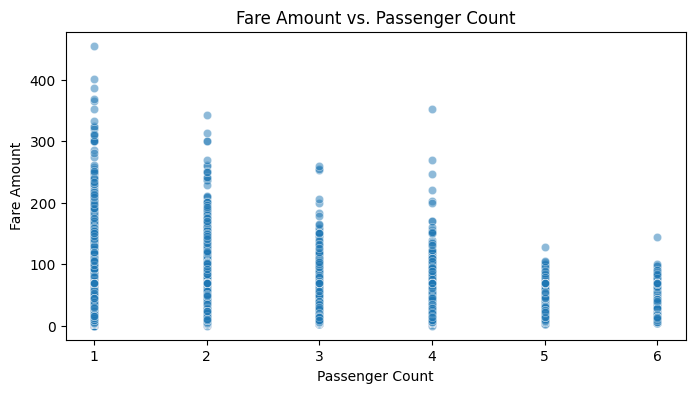

In [49]:
# Show relationship between fare and number of passengers
correlation_fare_passengers = df_non_zero[['fare_amount', 'passenger_count']].corr().loc['fare_amount', 'passenger_count']
print(f"Correlation between Fare Amount vs Passenger Count: {correlation_fare_passengers:.2f}")

plt.figure(figsize=(8, 4))
sns.scatterplot(y='fare_amount', x='passenger_count', data=df_non_zero, alpha=0.5)
plt.title('Fare Amount vs. Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount')
plt.show()

Correlation between Tip Amount vs Trip Distance: 0.59


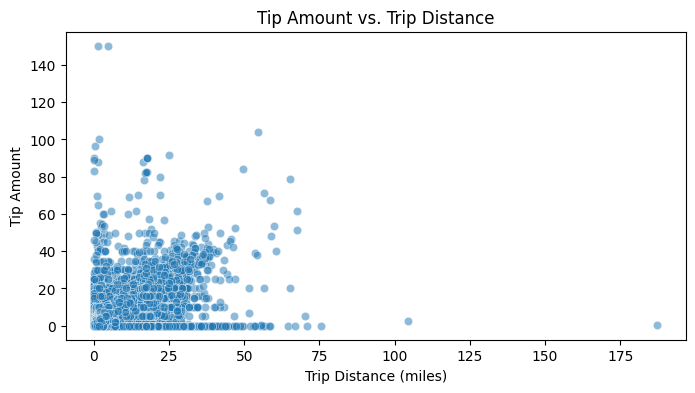

In [50]:
# Show relationship between tip and trip distance
correlation_tip_distance = df_non_zero[['tip_amount', 'trip_distance']].corr().loc['tip_amount', 'trip_distance']
print(f"Correlation between Tip Amount vs Trip Distance: {correlation_tip_distance:.2f}")

plt.figure(figsize=(8, 4))
sns.scatterplot(x='trip_distance', y='tip_amount', data=df_non_zero, alpha=0.5)
plt.title('Tip Amount vs. Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount')
plt.show()

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

In [51]:
df_non_zero['payment_type'].unique()

array([2, 1, 4, 3])

Distribution of Payment Types:
payment_type
1    236723
2     49798
4      1955
3      1050
Name: count, dtype: int64


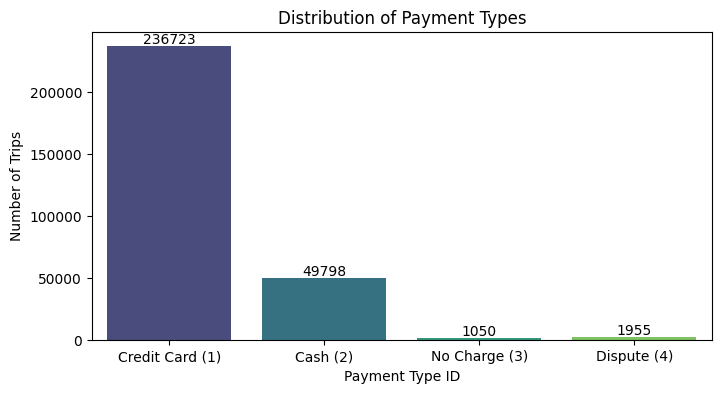

In [52]:
# Analyse the distribution of different payment types (payment_type).
payment_type_counts = df_non_zero['payment_type'].value_counts()

print("Distribution of Payment Types:")
print(payment_type_counts)

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=payment_type_counts.index, y=payment_type_counts.values, palette='viridis')
plt.title('Distribution of Payment Types')
plt.xlabel('Payment Type ID')
plt.ylabel('Number of Trips')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Credit Card (1)', 'Cash (2)', 'No Charge (3)', 'Dispute (4)'])

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.show()

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [53]:
# import geopandas as gpd
import geopandas as gpd

# Read the shapefile using geopandas
zones = gpd.read_file("/content/drive/MyDrive/Assignments/EDA/data_NYC_Taxi/taxi_zones/taxi_zones.shp")# read the .shp file using gpd
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

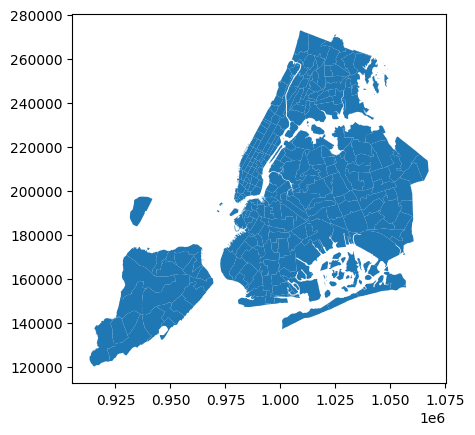

In [54]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [ ]:
# df_non_zero ---> df2

In [55]:
# Merge zones and trip records using locationID and PULocationID
df2 = pd.merge(df_non_zero, zones, left_on='PULocationID', right_on='LocationID', how='left')
df2.head()
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289545 entries, 0 to 289544
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               289545 non-null  int64         
 1   tpep_pickup_datetime   289545 non-null  datetime64[ns]
 2   tpep_dropoff_datetime  289545 non-null  datetime64[ns]
 3   passenger_count        289545 non-null  float64       
 4   trip_distance          289545 non-null  float64       
 5   RatecodeID             289545 non-null  float64       
 6   PULocationID           289545 non-null  int64         
 7   DOLocationID           289545 non-null  int64         
 8   payment_type           289545 non-null  int64         
 9   fare_amount            289545 non-null  float64       
 10  extra                  289545 non-null  float64       
 11  tip_amount             289545 non-null  float64       
 12  improvement_surcharge  289545 non-null  floa

**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [56]:
# Group data by location and calculate the number of trips
trips_per_location = df2.groupby("PULocationID").size().reset_index(name='trip_count')
trips_per_location.head()

,PULocationID,trip_count
0,1,5
1,3,8
2,4,281
3,5,2
4,6,3


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [57]:
# Merge trip counts back to the zones GeoDataFrame
zones_with_trips = pd.merge(zones, trips_per_location, left_on='LocationID', right_on='PULocationID', how='left')
zones_with_trips['trip_count'] = zones_with_trips['trip_count'].fillna(0) # Fill NaN for zones with no trips
zones_with_trips.shape

(263, 9)

The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

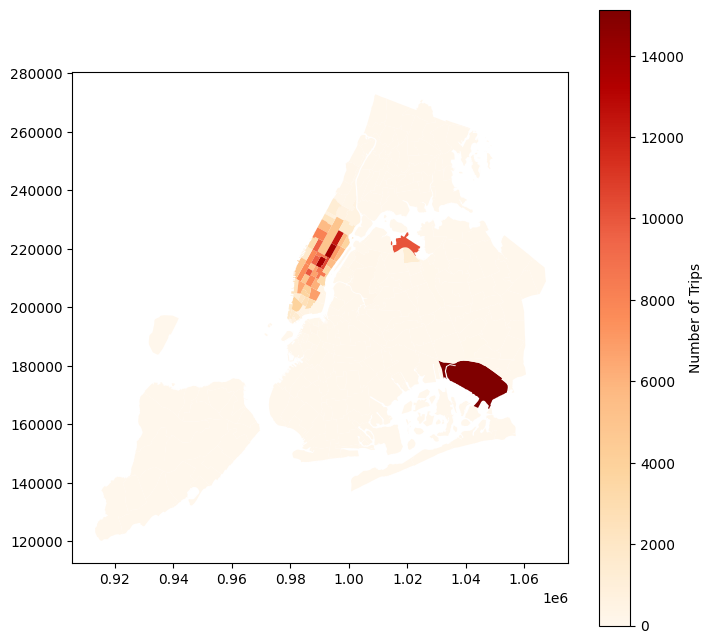

In [58]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize = (8, 8))

# Plot the map and display it
zones_with_trips.plot(
        column = 'trip_count',
        ax = ax,
        legend = True,
        legend_kwds = {'label': "Number of Trips", 'orientation': "vertical"},
        cmap='OrRd')
plt.show()

In [59]:
# can you try displaying the zones DF sorted by the number of trips?
zones_with_trips.sort_values(by='trip_count', ascending=False)[["zone","trip_count"]]

,zone,trip_count
131,JFK Airport,15135.0
236,Upper East Side South,13788.0
160,Midtown Center,13625.0
235,Upper East Side North,12329.0
161,Midtown East,10573.0
...,...,...
104,Governor's Island/Ellis Island/Liberty Island,0.0
103,Governor's Island/Ellis Island/Liberty Island,0.0
7,Astoria Park,0.0
83,Eltingville/Annadale/Prince's Bay,0.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [60]:
#Find routes which have the slowest speeds at different times of the day
route_hour = df2.groupby(['PULocationID','DOLocationID','pickup_hour']).agg(
    avg_distance=('trip_distance','mean'),
    avg_duration=('trip_duration','mean')
).reset_index()

route_hour['speed_mph'] = route_hour['avg_distance'] / (route_hour['avg_duration']/60)  #trip duration in min to hrs

# slowest route at each hour
slowest_routes = route_hour.sort_values('speed_mph').groupby('pickup_hour').head(1).sort_values(['speed_mph','pickup_hour'])
slowest_routes.sort_values("pickup_hour")

,PULocationID,DOLocationID,pickup_hour,avg_distance,avg_duration,speed_mph
12344,88,144,0,1.780000,1425.466667,0.074923
40645,164,263,1,3.682000,297.156667,0.743446
47033,229,137,2,1.310000,480.500000,0.163580
33247,148,238,3,6.040000,1429.983333,0.253430
48007,230,51,4,16.960000,1417.666667,0.717799
48929,230,230,5,0.180000,29.583333,0.365070
42804,185,168,6,0.300000,21.816667,0.825057
19687,128,128,7,0.020000,10.400000,0.115385
5412,50,43,8,1.420000,1431.333333,0.059525
30059,142,232,9,6.710000,1411.400000,0.285249


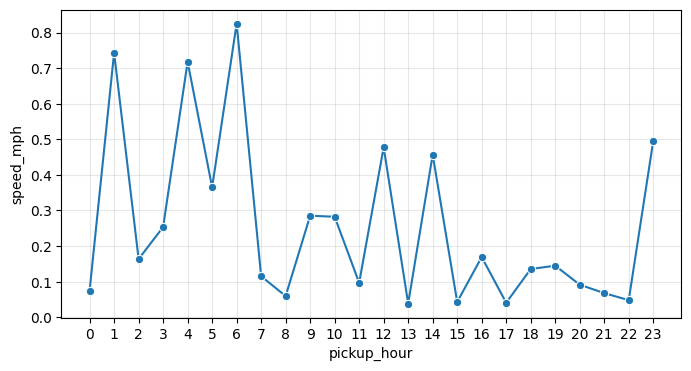

In [61]:
plt.figure(figsize=(8,4))
sns.lineplot(x=slowest_routes['pickup_hour'],y=slowest_routes['speed_mph'],marker='o')
plt.xticks(range(0,24))
plt.grid(True,alpha=0.3);

How does identifying high-traffic, high-demand routes help us?

<font color="yellow">Serve customers quickly while maximizing earnings. Use data to plan routes, pricing, and promotions. Optimize driver allocation by positioning vehicles where demand is highest.</font>

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

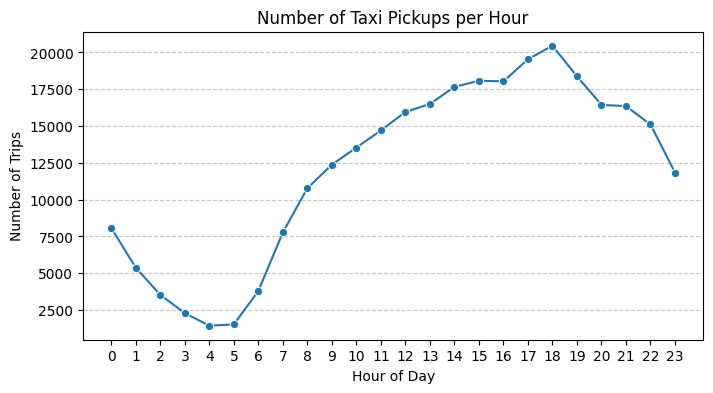

The busiest hour of the day is 18:00 with 20453 trips.


In [62]:
# Visualise the number of trips per hour and find the busiest hour
hourly_trip_counts = df2['pickup_hour'].value_counts().sort_index()
busiest_hour = hourly_trip_counts.idxmax()
max_trips = hourly_trip_counts.max()

plt.figure(figsize=(8, 4))
sns.lineplot(x=hourly_trip_counts.index, y=hourly_trip_counts.values,marker='o')
plt.title('Number of Taxi Pickups per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"The busiest hour of the day is {busiest_hour}:00 with {max_trips} trips.")

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [63]:
# Scale up the number of trips
sample_fraction = 0.008
Actual_trip_counts = hourly_trip_counts / sample_fraction
# Fill in the value of your sampling fraction and use that to scale up the numbers
Top_5_busiest_hours = Actual_trip_counts.sort_values(ascending=False).head()
print("Top_5_busiest_hours")
print(Top_5_busiest_hours.reset_index())

Top_5_busiest_hours
   pickup_hour      count
0           18  2556625.0
1           17  2441375.0
2           19  2297250.0
3           15  2258750.0
4           16  2254500.0


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

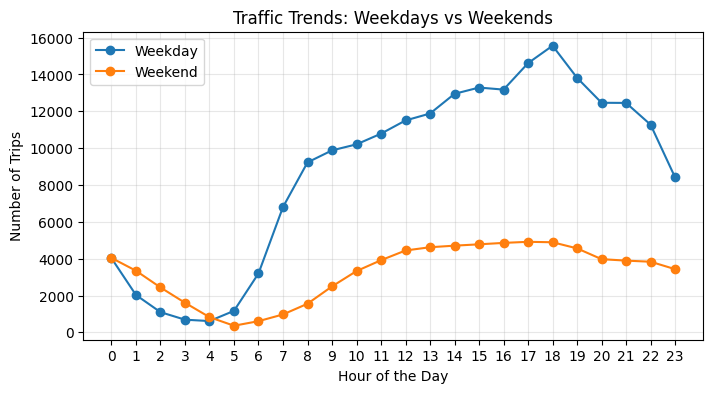

In [64]:
# Compare traffic trends for the week days and weekends
df2["weekday"] = df2["tpep_pickup_datetime"].dt.weekday

df2["day_type"] = df2["weekday"].apply(lambda x: "Weekend" if x >= 5 else "Weekday")

traffic_trends = df2.groupby(["day_type", "pickup_hour"]).size().reset_index(name="trip_count")

trend_pivot = traffic_trends.pivot(index="pickup_hour", columns="day_type", values="trip_count")

plt.figure(figsize=(8,4))
plt.plot(trend_pivot.index, trend_pivot["Weekday"], label="Weekday", marker="o")
plt.plot(trend_pivot.index, trend_pivot["Weekend"], label="Weekend", marker="o")

plt.title("Traffic Trends: Weekdays vs Weekends")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Trips")
plt.xticks(range(0,24))
plt.grid(True,alpha=0.3)
plt.legend()
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [65]:
# Find top 10 pickup and dropoff zones
pickup_counts = (
    df2.groupby(["PULocationID", "zone"])
      .size()
      .reset_index(name="trip_count")
      .sort_values("trip_count", ascending=False)
      .head(10))

print("Top 10 Pickup Zones:")
display(pickup_counts)

dropoff_counts = (
    df2.groupby(["DOLocationID", "zone"])
      .size()
      .reset_index(name="trip_count")
      .sort_values("trip_count", ascending=False)
      .head(10))

print("\nTop 10 Dropoff Zones:")
display(dropoff_counts)

Top 10 Pickup Zones:


,PULocationID,zone,trip_count
115,132,JFK Airport,15135
211,237,Upper East Side South,13788
143,161,Midtown Center,13625
210,236,Upper East Side North,12329
144,162,Midtown East,10573
121,138,LaGuardia Airport,10093
164,186,Penn Station/Madison Sq West,9989
204,230,Times Sq/Theatre District,9695
125,142,Lincoln Square East,9575
152,170,Murray Hill,8566



Top 10 Dropoff Zones:


,DOLocationID,zone,trip_count
8191,236,Upper East Side South,1957
8271,237,Upper East Side North,1719
8272,237,Upper East Side South,1331
8190,236,Upper East Side North,1287
5529,161,Upper East Side South,953
8245,237,Midtown Center,953
8170,236,Midtown Center,791
8392,239,Lincoln Square East,774
4804,142,Upper West Side South,758
8346,238,Upper West Side South,730


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [66]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
# Pickups
pickup_counts = (
    df2.groupby('PULocationID')
      .size()
      .reset_index(name='pickups')
)

# Dropoffs
dropoff_counts = (
    df2.groupby('DOLocationID')
      .size()
      .reset_index(name='dropoffs')
)
zone_flow = pickup_counts.merge(
    dropoff_counts,
    left_on='PULocationID',
    right_on='DOLocationID',
    how='outer'
)

# Fill missing (zones that appear only in pickups or only in dropoffs)
zone_flow['PULocationID'] = zone_flow['PULocationID'].fillna(zone_flow['DOLocationID'])
zone_flow = zone_flow.drop(columns=['DOLocationID'])

zone_flow = zone_flow.rename(columns={'PULocationID': 'LocationID'})
zone_flow['pickups'] = zone_flow['pickups'].fillna(0)
zone_flow['dropoffs'] = zone_flow['dropoffs'].fillna(0)

# Avoid divide-by-zero
zone_flow['dropoffs'] = zone_flow['dropoffs'].replace(0, 1)

# Pickup/Dropoff Ratio
zone_flow['pickup_dropoff_ratio'] = zone_flow['pickups'] / zone_flow['dropoffs']

zone_flow_named = zone_flow.merge(
    zones[['LocationID', 'zone', 'borough']],
    on='LocationID',
    how='left'
)

# Top 10 highest ratios
top_10_ratios = (
    zone_flow_named.sort_values('pickup_dropoff_ratio', ascending=False)
                   .head(10)
)

display(top_10_ratios)

# Bottom 10 lowest ratios
bottom_10_ratios = (
    zone_flow_named.sort_values('pickup_dropoff_ratio', ascending=True)
                   .head(10)
)


display(bottom_10_ratios)

,LocationID,pickups,dropoffs,pickup_dropoff_ratio,zone,borough
69,70.0,1326.0,145,9.144828,East Elmhurst,Queens
125,132.0,15135.0,3040,4.978618,JFK Airport,Queens
131,138.0,10093.0,3426,2.946001,LaGuardia Airport,Queens
178,186.0,9989.0,6509,1.534644,Penn Station/Madison Sq West,Manhattan
41,43.0,4963.0,3612,1.374031,Central Park,Manhattan
239,249.0,6472.0,4760,1.359664,West Village,Manhattan
108,114.0,3748.0,2804,1.336662,Greenwich Village South,Manhattan
155,162.0,10573.0,8331,1.269115,Midtown East,Manhattan
154,161.0,13625.0,11419,1.193187,Midtown Center,Manhattan
98,100.0,4749.0,3997,1.188141,Garment District,Manhattan


,LocationID,pickups,dropoffs,pickup_dropoff_ratio,zone,borough
175,183.0,0.0,10,0.0,Pelham Bay,Bronx
57,58.0,0.0,10,0.0,Country Club,Bronx
58,59.0,0.0,1,0.0,Crotona Park,Bronx
97,99.0,0.0,1,0.0,Freshkills Park,Staten Island
104,109.0,0.0,3,0.0,Great Kills,Staten Island
105,111.0,0.0,3,0.0,Green-Wood Cemetery,Brooklyn
149,156.0,0.0,2,0.0,Mariners Harbor,Staten Island
168,176.0,0.0,1,0.0,Oakwood,Staten Island
28,30.0,0.0,4,0.0,Broad Channel,Queens
25,27.0,0.0,6,0.0,Breezy Point/Fort Tilden/Riis Beach,Queens


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [67]:
# Filter for night hours (11 PM to 5 AM)
df_night_hours = df2[(df2['pickup_hour'] >= 23) | (df2['pickup_hour'] <= 5)]

print(df_night_hours.shape)

(34089, 29)


In [68]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

# Top pickup zones during night hours
night_pickup_counts = (
    df_night_hours.groupby(['PULocationID', 'zone'])
    .size()
    .reset_index(name='trip_count')
    .sort_values('trip_count', ascending=False)
    .head()
)

print("\nTop 10 Pickup Zones (Night Hours 11 PM - 5 AM):\n")
display(night_pickup_counts)

# Top dropoff zones during night hours
night_dropoff_counts = (
    df_night_hours.groupby(['DOLocationID', 'zone'])
    .size()
    .reset_index(name='trip_count')
    .sort_values('trip_count', ascending=False)
    .head()
)

print("\nTop 10 Dropoff Zones (Night Hours 11 PM - 5 AM):\n")
display(night_dropoff_counts)


Top 10 Pickup Zones (Night Hours 11 PM - 5 AM):



,PULocationID,zone,trip_count
50,79,East Village,2486
82,132,JFK Airport,2297
164,249,West Village,2008
28,48,Clinton East,1633
96,148,Lower East Side,1547



Top 10 Dropoff Zones (Night Hours 11 PM - 5 AM):



,DOLocationID,zone,trip_count
1235,79,East Village,145
1689,107,East Village,134
3146,170,East Village,130
1253,79,Lower East Side,126
1278,79,West Village,119


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [69]:
# Calculate total revenue for night hours
night_revenue = df_night_hours['total_amount'].sum()

# Filter for day hours (6 AM to 10 PM)
df_day_hours = df2[(df2['pickup_hour'] >= 6) & (df2['pickup_hour'] <= 22)]

# Calculate total revenue for day hours
day_revenue = df_day_hours['total_amount'].sum()

# Calculate overall total revenue
total_revenue = df2['total_amount'].sum()

# Calculate revenue share
night_revenue_share = (night_revenue / total_revenue) * 100
day_revenue_share = (day_revenue / total_revenue) * 100

print(f"Total Revenue during Night Hours (11 PM - 5 AM): ${night_revenue:,.2f}")
print(f"Share of Total Revenue during Night Hours: {night_revenue_share:.2f}%")
print(f"Total Revenue during Day Hours (6 AM - 10 PM): ${day_revenue:,.2f}")
print(f"Share of Total Revenue during Day Hours: {day_revenue_share:.2f}%")

Total Revenue during Night Hours (11 PM - 5 AM): $1,001,790.56
Share of Total Revenue during Night Hours: 12.04%
Total Revenue during Day Hours (6 AM - 10 PM): $7,315,357.67
Share of Total Revenue during Day Hours: 87.96%


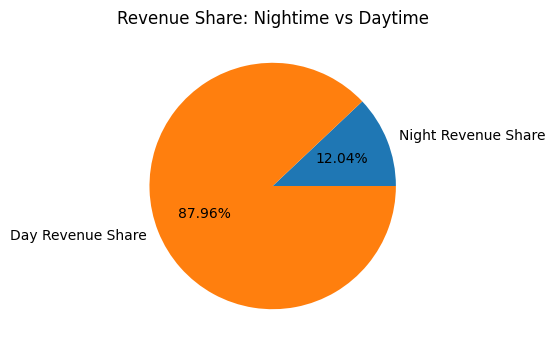

In [ ]:
plt.figure(figsize=(4,4))
plt.pie([night_revenue_share, day_revenue_share],autopct='%1.2f%%',labels=["Night Revenue Share","Day Revenue Share"])
plt.title('Revenue Share: Nightime vs Daytime');

##### Pricing Strategy

In [70]:
df2[["fare_amount","trip_distance"]].describe()

,fare_amount,trip_distance
count,289545.000000,289545.000000
mean,19.587161,3.478753
std,17.723010,4.532768
min,0.010000,0.010000
25%,9.300000,1.090000
50%,13.500000,1.800000
75%,21.900000,3.400000
max,455.200000,187.350000


<font color="yellow">While conducting detailed exploratory data analysis on pricing strategy, I found that "fare_amount" and "trip_distance" exhibit high variability,
which is impacting my analysis. Therefore, I decided to further clean up the data by handling outliers in those records.</font>

In [71]:
outlier_col = ["fare_amount","trip_distance"]

Q1 = df2[outlier_col].quantile(0.25)
Q3 = df2[outlier_col].quantile(0.75)

IQR = Q3 - Q1
LB = Q1 - 1.5*IQR
UB = Q3 + 1.5*IQR

# Create a boolean DataFrame indicating outliers in specified columns
outlier_mask_df = (df2[outlier_col] < LB) | (df2[outlier_col] > UB)

# Create a single boolean Series for rows: True if *any* column in the row is an outlier
final_outlier_mask = outlier_mask_df.any(axis=1)

# Filter the original DataFrame to keep only rows that are NOT outliers
df3 = df2[~final_outlier_mask].copy()

print(f"Original DataFrame shape: {df2.shape}")
print(f"DataFrame after outlier removal shape: {df3.shape}")

Original DataFrame shape: (289545, 29)
DataFrame after outlier removal shape: (250085, 29)


**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [72]:
# Analyse the fare per mile per passenger for different passenger counts
# Calculate the fare per mile for each trip
df3['fare_per_mile'] = df3['fare_amount'] / df3['trip_distance']

# Group by passenger count and calculate the average fare per mile
avg_fare_per_mile = df3.groupby('passenger_count')['fare_per_mile'].mean().reset_index()

# Calculate the average fare per mile per passenger
avg_fare_per_mile['fare_per_mile_per_passenger'] = avg_fare_per_mile['fare_per_mile'] / avg_fare_per_mile['passenger_count']

# Display the results
avg_fare_per_mile

,passenger_count,fare_per_mile,fare_per_mile_per_passenger
0,1.0,8.770658,8.770658
1,2.0,9.110312,4.555156
2,3.0,9.247927,3.082642
3,4.0,10.257903,2.564476
4,5.0,8.397846,1.679569
5,6.0,8.136741,1.356123


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [73]:
# Compare the average fare per mile for different days and for different times of the day

df3["fare_per_mile"] = df3["fare_amount"] / df3["trip_distance"]

# ---- AVERAGE FARE PER MILE BY HOUR ----
fare_by_hour = (
    df3.groupby("pickup_hour")["fare_per_mile"]
            .mean()
            .reset_index()
            .sort_values("pickup_hour")
)

# ---- AVERAGE FARE PER MILE BY WEEKDAY ----
df3["weekday"] = df3["tpep_pickup_datetime"].dt.dayofweek
# Mapping weekday names
weekday_map = {
    0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu",
    4: "Fri", 5: "Sat", 6: "Sun"
}

df3["weekday_name"] = df3["weekday"].map(weekday_map)

fare_by_weekday = (
    df3.groupby("weekday_name")["fare_per_mile"]
            .mean()
            .reset_index()
)

# Sort weekdays logically
fare_by_weekday["weekday_order"] = fare_by_weekday["weekday_name"].map(
    {"Mon":1,"Tue":2,"Wed":3,"Thu":4,"Fri":5,"Sat":6,"Sun":7}
)

fare_by_weekday = fare_by_weekday.sort_values("weekday_order").drop(columns="weekday_order")

print("Average Fare per Mile by Hour:")
display(fare_by_hour)

print("\nAverage Fare per Mile by Day of Week:")
display(fare_by_weekday)



Average Fare per Mile by Hour:


,pickup_hour,fare_per_mile
0,0,8.022895
1,1,7.731755
2,2,7.804513
3,3,7.945279
4,4,7.199451
5,5,6.917353
6,6,8.319380
7,7,7.867040
8,8,8.425845
9,9,8.697968



Average Fare per Mile by Day of Week:


,weekday_name,fare_per_mile
1,Mon,8.439669
5,Tue,9.056519
6,Wed,9.207288
4,Thu,9.305836
0,Fri,8.734041
2,Sat,8.666733
3,Sun,8.373486


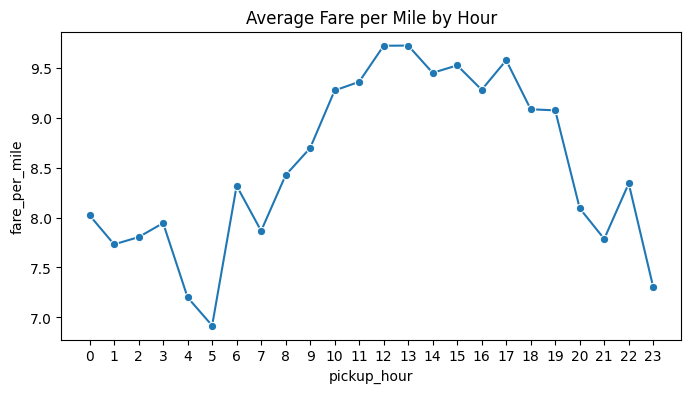

In [74]:
plt.figure(figsize=(8,4))
sns.lineplot(x=fare_by_hour['pickup_hour'],y=fare_by_hour['fare_per_mile'],marker='o')
plt.title("Average Fare per Mile by Hour")
plt.xticks(range(0,24));

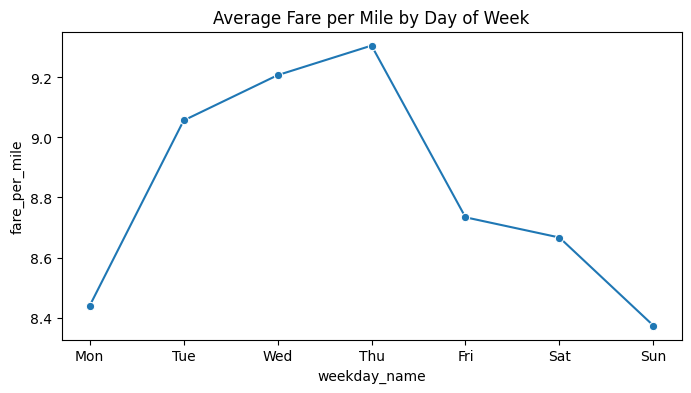

In [75]:
plt.figure(figsize=(8,4))
sns.lineplot(x=fare_by_weekday['weekday_name'],y=fare_by_weekday['fare_per_mile'],marker='o')
plt.title("Average Fare per Mile by Day of Week")
plt.xticks(range(0,7));

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [76]:
# Compare fare per mile for different vendors
vendor_hour_fare = (
    df3.groupby(["VendorID", "pickup_hour"])["fare_per_mile"]
    .mean().reset_index().sort_values(["VendorID", "pickup_hour"]))
display(vendor_hour_fare)

,VendorID,pickup_hour,fare_per_mile
0,1,0,6.984767
1,1,1,6.827549
2,1,2,6.899746
3,1,3,6.650158
4,1,4,6.791005
5,1,5,7.159155
6,1,6,7.077153
7,1,7,7.683039
8,1,8,8.281915
9,1,9,8.537560


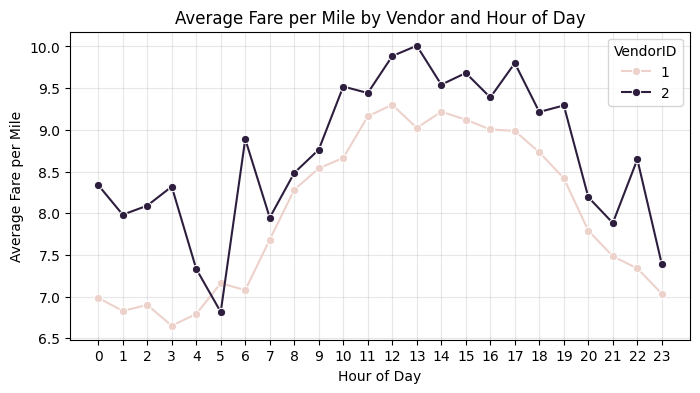

In [77]:
plt.figure(figsize=(8, 4))
sns.lineplot(x='pickup_hour', y='fare_per_mile', hue='VendorID', data=vendor_hour_fare, marker='o')
plt.title('Average Fare per Mile by Vendor and Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare per Mile')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend(title='VendorID')
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [78]:
# Defining distance tiers
def distance_tier(d):
    if d <= 2:
        return "0-2 miles"
    elif d <= 5:
        return "2-5 miles"
    else:
        return ">5 miles"

df3["distance_tier"] = df3["trip_distance"].apply(distance_tier)

# ---- Compute average fare per mile by vendor + tier ----
tier_analysis = (
    df3.groupby(["VendorID", "distance_tier"])["fare_per_mile"]
    .mean()
    .reset_index()
    .sort_values(["distance_tier", "VendorID"])
)

display(tier_analysis)


,VendorID,distance_tier,fare_per_mile
0,1,0-2 miles,9.605092
3,2,0-2 miles,10.547878
1,1,2-5 miles,6.342421
4,2,2-5 miles,6.507295
2,1,>5 miles,4.946539
5,2,>5 miles,5.059361


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

<font color="yellow">As the trip distance increases, the average tip percentage tends to decrease, suggesting passengers may tip less on longer, costlier trips. Passenger count shows no strong correlation with tip percentage.</font>

In [79]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
# Tip percentage
df3["tip_percent"] = df3["tip_amount"] / df3["fare_amount"] * 100

# 1: Tip % by trip distance categories
def distance_bin(d):
    if d <= 1: return "0–1 mile"
    elif d <= 3: return "1–3 miles"
    elif d <= 7: return "3–7 miles"
    else: return "7+ miles"

df3["distance_group"] = df3["trip_distance"].apply(distance_bin)

tip_by_distance = (
    df3.groupby("distance_group")["tip_percent"]
    .mean()
    .reset_index()
)
display(tip_by_distance)

,distance_group,tip_percent
0,0–1 mile,24.398920
1,1–3 miles,20.617915
2,3–7 miles,17.486204


In [80]:
# 2: Tip % by passenger count
tip_by_passengers = (
    df3.groupby("passenger_count")["tip_percent"]
    .mean()
    .reset_index()
)
display(tip_by_passengers)

,passenger_count,tip_percent
0,1.0,21.288161
1,2.0,20.505373
2,3.0,19.658918
3,4.0,18.125607
4,5.0,21.301132
5,6.0,21.230873


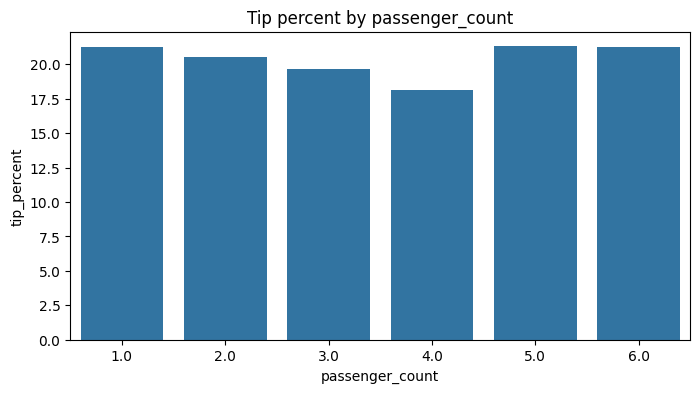

In [81]:
plt.figure(figsize=(8,4))
sns.barplot(x=tip_by_passengers["passenger_count"],y=tip_by_passengers["tip_percent"])
plt.title("Tip percent by passenger_count");

In [82]:
# 3: Tip % by pickup hour
tip_by_hour = (
    df3.groupby("pickup_hour")["tip_percent"]
    .mean()
    .reset_index()
)

display(tip_by_hour)

,pickup_hour,tip_percent
0,0,21.467050
1,1,22.238074
2,2,21.068475
3,3,21.432545
4,4,18.572254
5,5,17.890980
6,6,20.783662
7,7,20.165333
8,8,20.481107
9,9,19.948207


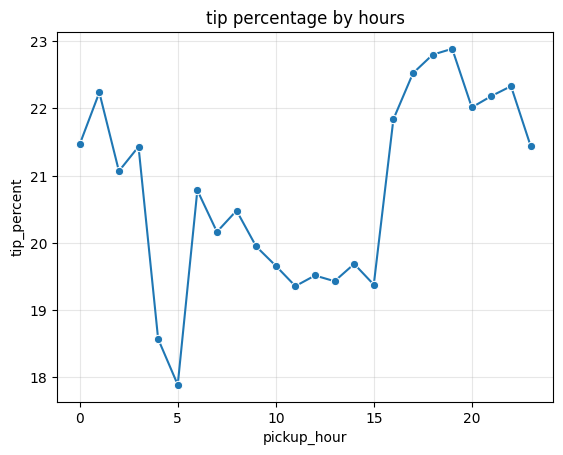

In [ ]:
sns.lineplot(x=tip_by_hour["pickup_hour"],y=tip_by_hour["tip_percent"],marker='o')
plt.title("tip percentage by hours")
plt.xticks(range(0,24))
plt.grid(True,alpha=0.3);

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [83]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

# Filter for low tip trips (<10%)
low_tip_trips = df3[df3['tip_percent'] < 10]

# Filter for high tip trips (>25%)
high_tip_trips = df3[df3['tip_percent'] > 25]

print("\n--- Low Tip Trips (Tip % < 10%) ---")
display(low_tip_trips.head())
print(f"Shape: {low_tip_trips.shape}")

print("\n--- High Tip Trips (Tip % > 25%) ---")
display(high_tip_trips.head())
print(f"Shape: {high_tip_trips.shape}")


--- Low Tip Trips (Tip % < 10%) ---


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,LocationID,borough,geometry,weekday,day_type,fare_per_mile,weekday_name,distance_tier,tip_percent,distance_group
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,237,141,2,11.4,...,237.0,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",6,Weekend,7.916667,Sun,0-2 miles,0.0,1–3 miles
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,143,142,2,6.5,...,143.0,Manhattan,"POLYGON ((989338.1 223572.253, 989368.225 2235...",6,Weekend,12.037037,Sun,0-2 miles,0.0,0–1 mile
9,2,2023-01-01 00:14:47,2023-01-01 00:20:18,1.0,0.78,1.0,237,229,2,7.2,...,237.0,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",6,Weekend,9.230769,Sun,0-2 miles,0.0,0–1 mile
14,2,2023-01-01 00:56:42,2023-01-01 01:00:25,1.0,0.74,1.0,229,141,1,5.8,...,229.0,Manhattan,"POLYGON ((994880.664 214401.395, 994724.359 21...",6,Weekend,7.837838,Sun,0-2 miles,0.0,0–1 mile
20,2,2023-01-01 00:47:20,2023-01-01 01:31:34,6.0,4.69,1.0,90,238,2,40.1,...,90.0,Manhattan,"POLYGON ((985265.129 208165.863, 985125.733 20...",6,Weekend,8.550107,Sun,2-5 miles,0.0,3–7 miles


Shape: (63133, 34)

--- High Tip Trips (Tip % > 25%) ---


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,LocationID,borough,geometry,weekday,day_type,fare_per_mile,weekday_name,distance_tier,tip_percent,distance_group
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,161,237,1,7.9,...,161.0,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",6,Weekend,6.370968,Sun,0-2 miles,32.658228,1–3 miles
5,2,2023-01-01 00:58:00,2023-01-01 01:08:31,2.0,1.59,1.0,79,164,1,11.4,...,79.0,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20...",6,Weekend,7.169811,Sun,0-2 miles,28.771930,1–3 miles
6,2,2023-01-01 00:16:06,2023-01-01 00:31:59,1.0,3.16,1.0,79,256,1,19.1,...,79.0,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20...",6,Weekend,6.044304,Sun,2-5 miles,31.518325,3–7 miles
10,2,2023-01-01 00:24:48,2023-01-01 00:45:04,1.0,2.78,1.0,79,186,1,19.8,...,79.0,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20...",6,Weekend,7.122302,Sun,2-5 miles,25.050505,1–3 miles
11,2,2023-01-01 00:27:33,2023-01-01 00:36:38,2.0,0.85,1.0,90,68,1,10.0,...,90.0,Manhattan,"POLYGON ((985265.129 208165.863, 985125.733 20...",6,Weekend,11.764706,Sun,0-2 miles,37.500000,0–1 mile


Shape: (120601, 34)


<font color="yellow">Let's also visualize the distribution of `pickup_hour` and `payment_type` for both groups.</font>

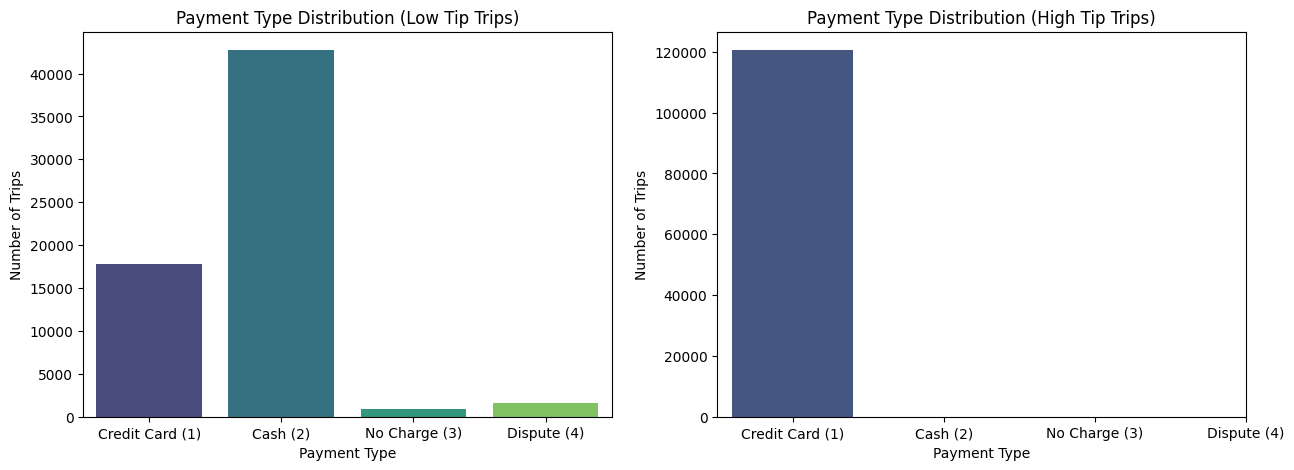

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(x='payment_type', data=low_tip_trips, ax=axes[0], palette='viridis')
axes[0].set_title('Payment Type Distribution (Low Tip Trips)')
axes[0].set_xlabel('Payment Type')
axes[0].set_ylabel('Number of Trips')
axes[0].set_xticks(ticks=[0, 1, 2, 3], labels=['Credit Card (1)', 'Cash (2)', 'No Charge (3)', 'Dispute (4)'])

sns.countplot(x='payment_type', data=high_tip_trips, ax=axes[1], palette='viridis')
axes[1].set_title('Payment Type Distribution (High Tip Trips)')
axes[1].set_xlabel('Payment Type')
axes[1].set_ylabel('Number of Trips')
axes[1].set_xticks(ticks=[0, 1, 2, 3], labels=['Credit Card (1)', 'Cash (2)', 'No Charge (3)', 'Dispute (4)'])

plt.show()

**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

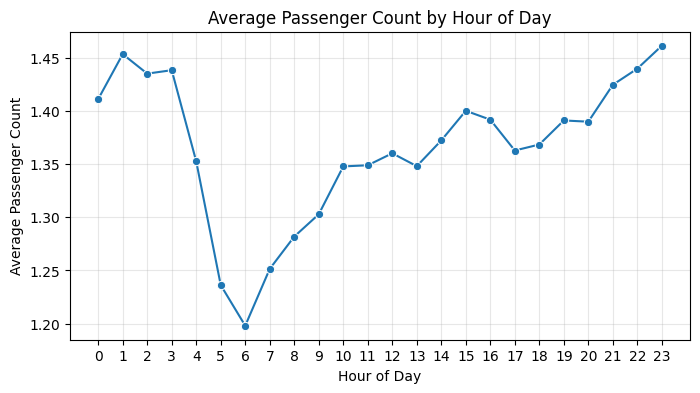

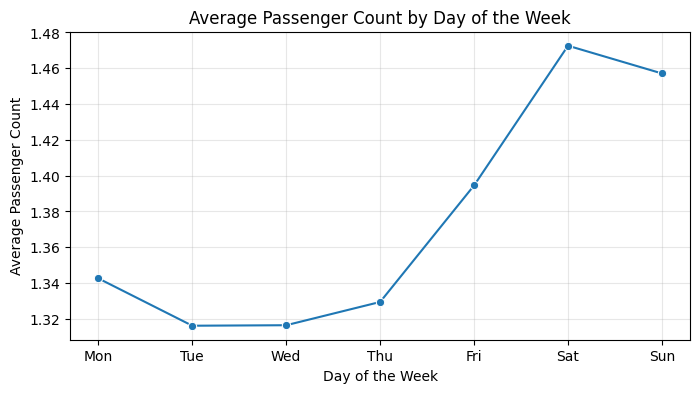

In [85]:
# See how passenger count varies across hours and days

# Average passenger count by hour of day
passenger_count_by_hour = df3.groupby('pickup_hour')['passenger_count'].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.lineplot(x='pickup_hour', y='passenger_count', data=passenger_count_by_hour, marker='o')
plt.title('Average Passenger Count by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Passenger Count')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

# Average passenger count by day of the week
passenger_count_by_day = df3.groupby('weekday_name')['passenger_count'].mean().reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']).reset_index()

plt.figure(figsize=(8, 4))
sns.lineplot(x='weekday_name', y='passenger_count', data=passenger_count_by_day, marker='o')
plt.title('Average Passenger Count by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Passenger Count')
plt.grid(True, alpha=0.3)
plt.show()

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [86]:
# How does passenger count vary across zones

# Calculate average passenger count per pickup zone
avg_passenger_count_per_zone = df2.groupby('PULocationID')['passenger_count'].mean().reset_index()

# Merge with zones data to get zone names and boroughs
avg_passenger_count_per_zone = pd.merge(avg_passenger_count_per_zone, zones[['LocationID', 'zone', 'borough']], left_on='PULocationID', right_on='LocationID', how='left')
avg_passenger_count_per_zone = avg_passenger_count_per_zone.drop(columns='LocationID') # Drop the redundant LocationID column

# Display top 10 zones with highest average passenger count
print("\nTop 10 Zones by Average Passenger Count (Pickup):")
display(avg_passenger_count_per_zone.sort_values(by='passenger_count', ascending=False).head(10))

# Display bottom 10 zones with lowest average passenger count
print("\nBottom 10 Zones by Average Passenger Count (Pickup):")
display(avg_passenger_count_per_zone.sort_values(by='passenger_count', ascending=True).head(10))


Top 10 Zones by Average Passenger Count (Pickup):


,PULocationID,passenger_count,zone,borough
0,1,2.000000,Newark Airport,EWR
227,253,2.000000,Willets Point,Queens
4,6,2.000000,Arrochar/Fort Wadsworth,Staten Island
105,120,2.000000,Highbridge Park,Manhattan
139,154,2.000000,Marine Park/Floyd Bennett Field,Brooklyn
204,228,2.000000,Sunset Park West,Brooklyn
61,67,1.800000,Dyker Heights,Brooklyn
174,195,1.772727,Red Hook,Brooklyn
173,194,1.750000,Randalls Island,Manhattan
9,12,1.740157,Battery Park,Manhattan



Bottom 10 Zones by Average Passenger Count (Pickup):


,PULocationID,passenger_count,zone,borough
226,252,1.0,Whitestone,Queens
71,77,1.0,East New York/Pennsylvania Avenue,Brooklyn
134,149,1.0,Madison,Brooklyn
138,153,1.0,Marble Hill,Manhattan
67,73,1.0,East Flushing,Queens
66,72,1.0,East Flatbush/Remsen Village,Brooklyn
65,71,1.0,East Flatbush/Farragut,Brooklyn
140,155,1.0,Marine Park/Mill Basin,Brooklyn
218,242,1.0,Van Nest/Morris Park,Bronx
149,165,1.0,Midwood,Brooklyn


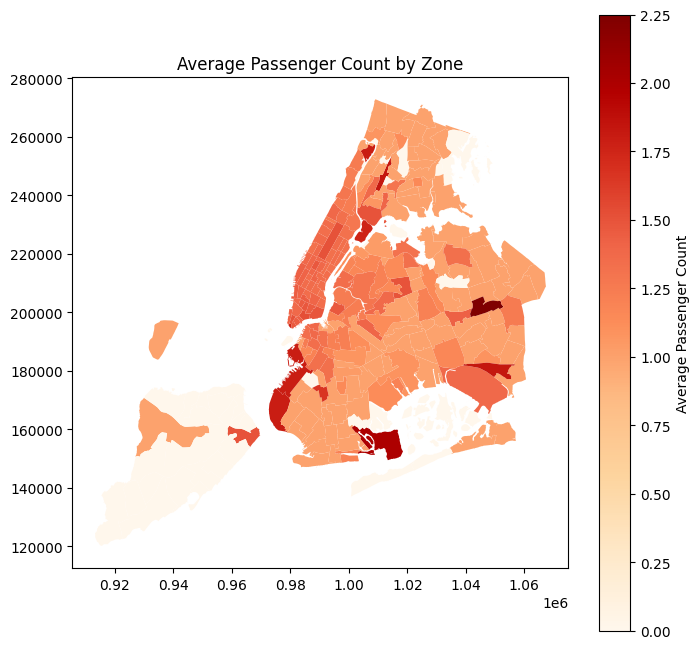

In [87]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

# Calculate the average passenger count for each zone
avg_passenger_count_by_zone = df3.groupby('PULocationID')['passenger_count'].mean().reset_index()

# Merge the average passenger count with the zones_with_trips GeoDataFrame
zones_with_trips = zones_with_trips.merge(avg_passenger_count_by_zone, left_on='LocationID', right_on='PULocationID', how='left')

# Fill NaN values with 0 (for zones with no trips)
zones_with_trips['passenger_count'].fillna(0, inplace=True)

# Plot the average passenger count for each zone using a Geo Plot
zones_with_trips.plot(column='passenger_count', cmap='OrRd', legend=True, legend_kwds={'label': "Average Passenger Count", 'orientation': "vertical"}, figsize=(8, 8))
plt.title('Average Passenger Count by Zone')
plt.show()

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [88]:
# How often is each surcharge applied?

# Surcharge columns
surcharge_cols = ['extra', 'congestion_surcharge', 'airport_fee']

print("Prevalence of Surcharges:")
for col in surcharge_cols:
    # Count trips where the surcharge is greater than 0
    applied_count = df3[df3[col] > 0].shape[0]
    # Calculate the percentage of trips where the surcharge is applied
    percentage = (applied_count / df2.shape[0]) * 100
    print(f"  {col}: {applied_count} trips ({percentage:.2f}%)")


Prevalence of Surcharges:
  extra: 154258 trips (53.28%)
  congestion_surcharge: 241236 trips (83.32%)
  airport_fee: 2572 trips (0.89%)


In [89]:
# Analyze the pickup zones where surcharges are applied more frequently
pickup_surcharge_zones = df2[df2[surcharge_cols].sum(axis=1) > 0].groupby('PULocationID').size().reset_index(name='surcharge_count')
pickup_surcharge_zones = pickup_surcharge_zones.merge(zones[['LocationID', 'zone']], left_on='PULocationID', right_on='LocationID', how='left').sort_values(by='surcharge_count', ascending=False)

# Display the top pickup zones with surcharges
print("Top pickup zones with surcharges:")
display(pickup_surcharge_zones.head())

Top pickup zones with surcharges:


,PULocationID,surcharge_count,LocationID,zone
83,132,14862,132.0,JFK Airport
155,237,13762,237.0,Upper East Side South
103,161,13555,161.0,Midtown Center
154,236,12292,236.0,Upper East Side North
104,162,10534,162.0,Midtown East


In [90]:
# Analyze the dropoff zones where surcharges are applied more frequently
dropoff_surcharge_zones = df2[df2[surcharge_cols].sum(axis=1) > 0].groupby('DOLocationID').size().reset_index(name='surcharge_count')
dropoff_surcharge_zones = dropoff_surcharge_zones.merge(zones[['LocationID', 'zone']], left_on='DOLocationID', right_on='LocationID', how='left').sort_values(by='surcharge_count', ascending=False)

# Display the top dropoff zones with surcharges
print("Top dropoff zones with surcharges:")
display(dropoff_surcharge_zones.head())

Top dropoff zones with surcharges:


,DOLocationID,surcharge_count,LocationID,zone
226,236,12974,236.0,Upper East Side North
227,237,12272,237.0,Upper East Side South
154,161,11401,161.0,Midtown Center
220,230,8819,230.0,Times Sq/Theatre District
163,170,8658,170.0,Murray Hill


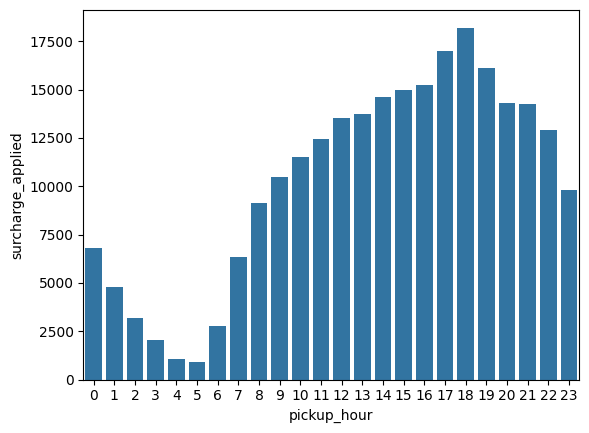

In [91]:
# Analyze the times when surcharges are applied more frequently
df3['surcharge_applied'] = df3[surcharge_cols].sum(axis=1) > 0
surcharge_by_hour = df3.groupby('pickup_hour')['surcharge_applied'].sum().reset_index()

sns.barplot(x=surcharge_by_hour['pickup_hour'],y=surcharge_by_hour['surcharge_applied']);

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

* Strategically position more taxis in high-demand areas (e.g., Midtown, Upper East Side, JFK Airport) during peak hours (17:00-19:00 on weekdays, later evenings on weekends)(section 3.2.2 and 3.2.3).
* For identified "slow routes" (e.g., Route 234-256 at 18:00), integrate real-time traffic data to recommend alternative routes to drivers. Consider pre-emptive traffic management to minimise travel time and improve service efficiency. (section 3.2.1)
* Implement surge pricing in high-demand zones during daytime peak periods. (section 3.2.5)
* Offer incentives to drivers for operating in historically slow areas during off-peak hours to improve service coverage and reduce wait times.
* Repositioning algorithms can be implemented for cab positioning to address demand surges in specific areas, taking into account current traffic, historical speeds, and predicted demand to minimise trip duration and fuel consumption.


**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

* During weekday morning (7-10 AM) and evening (4-7 PM) peaks, concentrate cabs in major business districts and residential areas with high outbound commuter traffic (e.g., Midtown, Financial District, Upper East Side/West Side).
* Shift cab distribution towards entertainment hubs, tourist attractions, and residential areas with high evening social activity on weekends (e.g., East Village, West Village, Times Square).
* Maintain a consistent and adequate supply of taxis at JFK and LaGuardia Airports, especially during peak travel times. Utilize the high passenger counts at these locations to ensure efficient allocation.
* Deploy more empty cabs to high pickup ratio zones (origins) and encourage drivers to move from high dropoff ratio zones (destinations) to nearby high-demand pickup areas.(section 3.2.6)
* For night hours (11 PM - 5 AM), position cabs strategically in popular nightlife areas and residential zones with high night-time activity like East Village, West Village, and parts of Midtown. Implement surge pricing (night charges) during these hours to incentivize drivers.(section 3.2.7)


**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

* July–September show low revenue; offering competitive or promotional pricing during these months and off-peak hours can boost pickups and overall earnings.(section 3.1.4)
* Correlation between trip duration and fare is low (0.29). The company can impose a waiting charge for the ride, which will increase the correlation between these two variables.(section 3.1.7)
* If Vendor 2 consistently charges higher fares per mile, and customers are still choosing them, it might indicate a perceived higher service quality. Investigate if there are opportunities to match or slightly undercut Vendor 2's pricing while improving service. If Vendor 1 has a lower fare per mile, market this as a competitive advantage.(section 3.2.11)
* Re-evaluate the fare-per-mile structure for different distance tiers. While shorter trips (0-2 miles) currently have a higher fare/mile, consider optimizing the pricing for longer trips (>5 miles) to ensure competitiveness, especially if Vendor 2's pricing is more favorable in these segments.(section 3.2.12)
* Implement programs to encourage higher tipping behavior, especially in scenarios associated with low tips (e.g., cash payments, early morning rides). This could involve driver quality incentives or promotional messaging to customers.(section 3.2.13)
